In [14]:
import scipy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sk
import re

In [15]:
df = pd.read_csv("./dataset.csv", encoding="utf-8")
print(df.shape)
print(df.columns)

(5411, 15)
Index(['id', 'rec_price_m', 'price', 'city', 'lat', 'lon', 'bathrooms',
       'height', 'state', 'type', 'year', 'floor', 'max_floor', 'area',
       'views'],
      dtype='object')


In [16]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5411 entries, 0 to 5410
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           5411 non-null   int64  
 1   rec_price_m  5411 non-null   int64  
 2   price        5411 non-null   int64  
 3   city         5411 non-null   object 
 4   lat          5411 non-null   float64
 5   lon          5411 non-null   float64
 6   bathrooms    5411 non-null   int64  
 7   height       5411 non-null   float64
 8   state        5411 non-null   object 
 9   type         5411 non-null   object 
 10  year         5411 non-null   int64  
 11  floor        5411 non-null   int64  
 12  max_floor    5411 non-null   int64  
 13  area         5309 non-null   float64
 14  views        5309 non-null   float64
dtypes: float64(5), int64(7), object(3)
memory usage: 634.2+ KB
None


In [17]:
print(df.describe(include='all'))

print(df["city"])

                  id    rec_price_m         price    city          lat  \
count   5.411000e+03    5411.000000  5.411000e+03    5411  5411.000000   
unique           NaN            NaN           NaN      22          NaN   
top              NaN            NaN           NaN  Алматы          NaN   
freq             NaN            NaN           NaN    2877          NaN   
mean    9.465911e+08  683880.175568  4.492300e+07     NaN    46.711685   
std     1.248705e+08  141820.611148  2.497521e+07     NaN     3.916172   
min     1.624520e+07  174130.000000  2.000000e+01     NaN    42.293369   
25%     1.003333e+09  602610.000000  2.850000e+07     NaN    43.237285   
50%     1.009084e+09  670390.000000  3.850000e+07     NaN    43.313626   
75%     1.010558e+09  785145.000000  5.500000e+07     NaN    51.119176   
max     1.011461e+09  997820.000000  3.500000e+08     NaN    54.932426   

                lon    bathrooms       height             state        type  \
count   5411.000000  5411.000000

In [18]:
categorial = ['city', 'state', 'type']
for cat in categorial:
    df[cat] = df[cat].str.lower()

df['city'] = df['city'].str.replace("показать на карте", "")
print(df['city'].unique())

['астана' 'алматы' 'уральск' 'костанай' 'усть-каменогорск' 'атырау'
 'актобе' 'тараз' 'семей' 'шымкент' 'караганда' 'талдыкорган' 'актау'
 'кокшетау' 'павлодар' 'петропавловск' 'темиртау' 'кызылорда' 'туркестан']


In [19]:
states = [
    'не новый, но аккуратный ремонт',
    'требует ремонта',
    'черновая отделка',
    'свежий ремонт',
    'свободная планировка'
]

df['state'] = df['state'].str.replace("'", "")

def normalize_state(text):
    for s in states:
        if s in text:
            return s
    return text

df['state'] = df['state'].apply(normalize_state)

print(df["state"].unique())

['не новый, но аккуратный ремонт' 'свежий ремонт' 'черновая отделка'
 'свободная планировка' 'требует ремонта']


In [20]:
types = ['кирпичный', 'монолитный', 'панельный', 'иной']

def normalize_type(text):
    for s in types:
        if s in text:
            return s
    return None


df['type'] = df['type'].apply(normalize_type)

print(df["type"].unique())

['кирпичный' 'монолитный' None 'панельный' 'иной']


In [21]:
print(df.shape)
df = df.dropna()
print(df.shape)

(5411, 15)
(5033, 15)


In [22]:
print(df.describe(include='all'))

                  id    rec_price_m         price    city          lat  \
count   5.033000e+03    5033.000000  5.033000e+03    5033  5033.000000   
unique           NaN            NaN           NaN      19          NaN   
top              NaN            NaN           NaN  алматы          NaN   
freq             NaN            NaN           NaN    2771          NaN   
mean    9.454181e+08  685329.594675  4.491160e+07     NaN    46.648985   
std     1.259871e+08  141667.039588  2.463881e+07     NaN     3.904210   
min     1.624520e+07  174130.000000  5.000000e+05     NaN    42.293369   
25%     1.003325e+09  604660.000000  2.850000e+07     NaN    43.236956   
50%     1.009061e+09  671330.000000  3.850000e+07     NaN    43.306576   
75%     1.010553e+09  786360.000000  5.500000e+07     NaN    51.118436   
max     1.011461e+09  997820.000000  3.500000e+08     NaN    54.903252   

                lon    bathrooms       height             state        type  \
count   5033.000000  5033.000000

In [23]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # радиус Земли в км

    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

city_centers = df.groupby('city').agg(
    lat_med = ('lat', 'median'),
    lon_med = ('lon', 'median')
)
city_centers.to_csv("city_centers.csv")

df['dist'] = df.apply(
    lambda x: haversine(x['lat'], x['lon'], city_centers.loc[x['city'], 'lat_med'], city_centers.loc[x['city'], 'lon_med']),
    axis = 1
)


In [24]:
df["cur_price_m"] = df["price"] / df["area"]
df["delta"] = df["rec_price_m"] - df["cur_price_m"]

1285


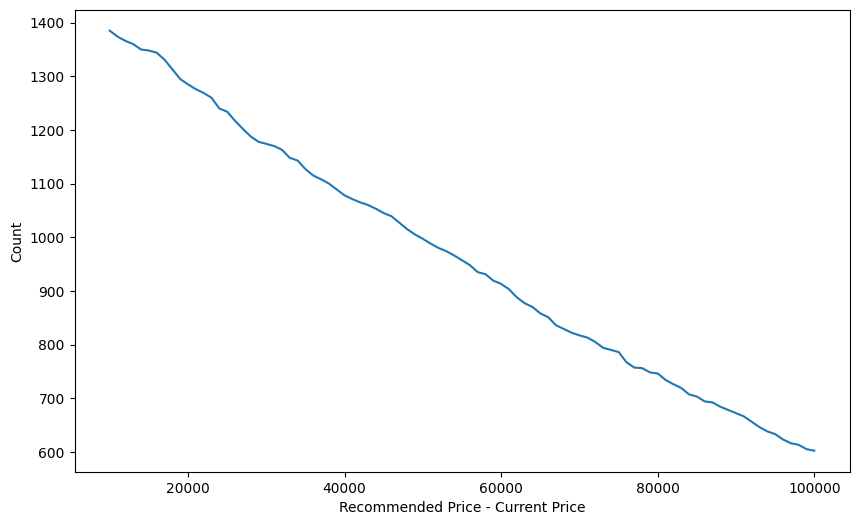

In [25]:
print((df["delta"] > 20000).sum())

x_values = []
y_values = []

plt.figure(figsize=(10, 6))
plt.xlabel("Recommended Price - Current Price")
plt.ylabel("Count")
for i in range(10000, 100001, 1000):
    x_values.append(i)
    y_values.append((df["delta"] > i).sum())
plt.plot(x_values, y_values)

1285


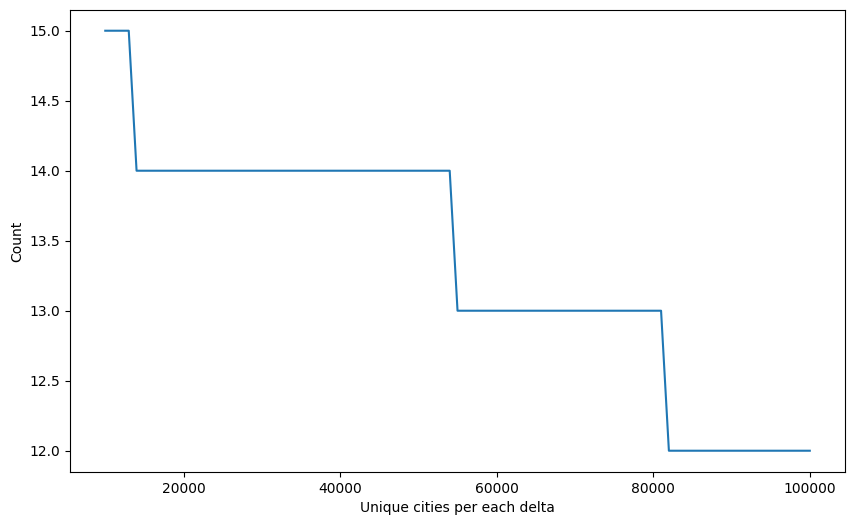

In [26]:
print((df["delta"] > 20000).sum())

x_values = []
y_values = []

plt.figure(figsize=(10, 6))
plt.xlabel("Unique cities per each delta")
plt.ylabel("Count")
for i in range(10000, 100001, 1000):
    x_values.append(i)
    y_values.append( len( df[(df["delta"] > i)]['city'].unique()) )

plt.plot(x_values, y_values)

In [27]:
cities_delta = df.groupby("city")["delta"].quantile(0.85)
df["quantile"] = df.groupby("city")["delta"].transform('quantile', q=0.85)

In [28]:
df['rating'] = df.groupby('city')['delta'].transform(
    lambda x: pd.qcut(x, q=10, labels=False, duplicates='drop')
)

#df['rating'] = df['rating'] * 0.5 + 0.5

In [29]:
print(df['rating'].min(), df['rating'].max())

0.0 9.0


In [30]:
print(df.columns)
df = df.dropna()
df_result = df.copy(deep=True)
df_buf = df.copy(deep=True)

df_result = df_result.drop(columns=["rec_price_m", "price", "quantile", "lat", "lon", "id", "delta"])

state_map = {
    'не новый, но аккуратный ремонт' : 1,
    'требует ремонта' : 2,
    'черновая отделка' : 3,
    'свежий ремонт' : 4,
    'свободная планировка' : 5
}
df_result['state'] = df_result['state'].map(state_map).fillna(2) 

#print(df_result['type'].unique())

types_map = {
    'кирпичный' : 1,
    'монолитный' : 2, 
    'панельный' : 3,
    'иной' : 4
}
df_result['type'] = df_result['type'].map(types_map).fillna(4)

cur_cities = df['city'].unique()
city_map = {city: i + 1 for i, city in enumerate(cur_cities)}
df_result['city'] = df_result['city'].map(city_map)

print(city_map)

#city_map = {df['city'].unique() : np.linspace(1, l)}

#print(df_result['type'].unique(), df_result['state'].unique())

#print(df_result.columns)
df_result.to_csv('cities_delta_results.csv', index=False, encoding='utf-8-sig')

#print(df_result.describe(include='all'))

Index(['id', 'rec_price_m', 'price', 'city', 'lat', 'lon', 'bathrooms',
       'height', 'state', 'type', 'year', 'floor', 'max_floor', 'area',
       'views', 'dist', 'cur_price_m', 'delta', 'quantile', 'rating'],
      dtype='object')
{'астана': 1, 'алматы': 2, 'костанай': 3, 'усть-каменогорск': 4, 'атырау': 5, 'актобе': 6, 'тараз': 7, 'шымкент': 8, 'караганда': 9, 'семей': 10, 'талдыкорган': 11, 'кокшетау': 12, 'актау': 13, 'павлодар': 14, 'уральск': 15, 'петропавловск': 16, 'темиртау': 17}


In [31]:
df = df_result
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 5031 entries, 0 to 5410
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   city         5031 non-null   int64  
 1   bathrooms    5031 non-null   int64  
 2   height       5031 non-null   float64
 3   state        5031 non-null   int64  
 4   type         5031 non-null   int64  
 5   year         5031 non-null   int64  
 6   floor        5031 non-null   int64  
 7   max_floor    5031 non-null   int64  
 8   area         5031 non-null   float64
 9   views        5031 non-null   float64
 10  dist         5031 non-null   float64
 11  cur_price_m  5031 non-null   float64
 12  rating       5031 non-null   float64
dtypes: float64(6), int64(7)
memory usage: 550.3 KB
None


In [32]:
print(df['rating'].unique())

print(df[(df['rating'].isna())])
print(df_result.shape)

[7. 9. 3. 6. 0. 1. 4. 8. 5. 2.]
Empty DataFrame
Columns: [city, bathrooms, height, state, type, year, floor, max_floor, area, views, dist, cur_price_m, rating]
Index: []
(5031, 13)


In [33]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

feature_cols = [c for c in df_result.columns if c != 'rating']

X = df[feature_cols]
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    objective='multi:softmax',
    num_class=10,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

print(classification_report(y_test, model.predict(X_test), target_names=[f'{i+1}★' for i in range(10)]))


[0]	validation_0-mlogloss:2.18850
[50]	validation_0-mlogloss:1.02986
[100]	validation_0-mlogloss:0.87090
[150]	validation_0-mlogloss:0.80246
[200]	validation_0-mlogloss:0.75783
[250]	validation_0-mlogloss:0.72360
[299]	validation_0-mlogloss:0.70091
              precision    recall  f1-score   support

          1★       0.99      0.94      0.96       102
          2★       0.95      0.98      0.97       102
          3★       0.96      0.99      0.98        99
          4★       0.90      0.92      0.91       101
          5★       0.75      0.75      0.75       102
          6★       0.59      0.52      0.55        98
          7★       0.51      0.53      0.52       101
          8★       0.52      0.47      0.49       100
          9★       0.54      0.55      0.55       100
         10★       0.76      0.83      0.79       102

    accuracy                           0.75      1007
   macro avg       0.75      0.75      0.75      1007
weighted avg       0.75      0.75      0.75    

In [34]:
model.save_model('apartment_rating_model.json')

# Загрузить
#model = XGBClassifier()
#model.load_model('apartment_rating_model.json')

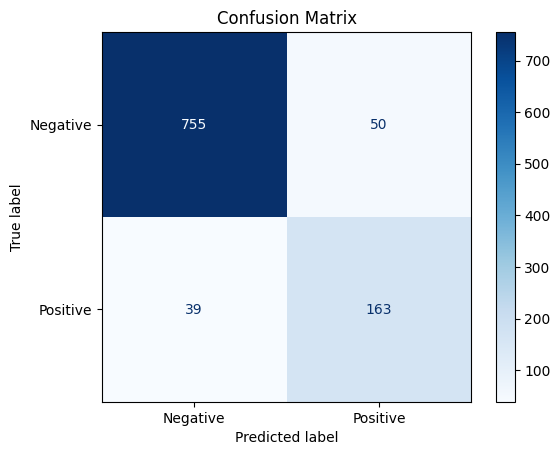

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ans = model.predict(X_test)

y_true = (y_test > 7).astype(int)
y_pred = (ans > 7).astype(int)


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [36]:
print(model.predict(X_test[:10]))
print(y_test[:10])

[0 4 5 8 1 0 7 9 0 7]
833     0.0
3840    4.0
2241    6.0
4054    8.0
2031    1.0
2563    0.0
482     7.0
385     9.0
2018    0.0
3064    8.0
Name: rating, dtype: float64


In [37]:
tn, fp, fn, tp = cm.ravel()

precision = tp / (tp + fp)
recall = tp / (tp + fn)
accuracy = (tp + tn) / (tp + tn + fp + fn)

print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, Accuracy: {accuracy:.2f}")


Precision: 0.77, Recall: 0.81, Accuracy: 0.91
